## Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Task 1: Data Understanding and Visualization:

##1.1 Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

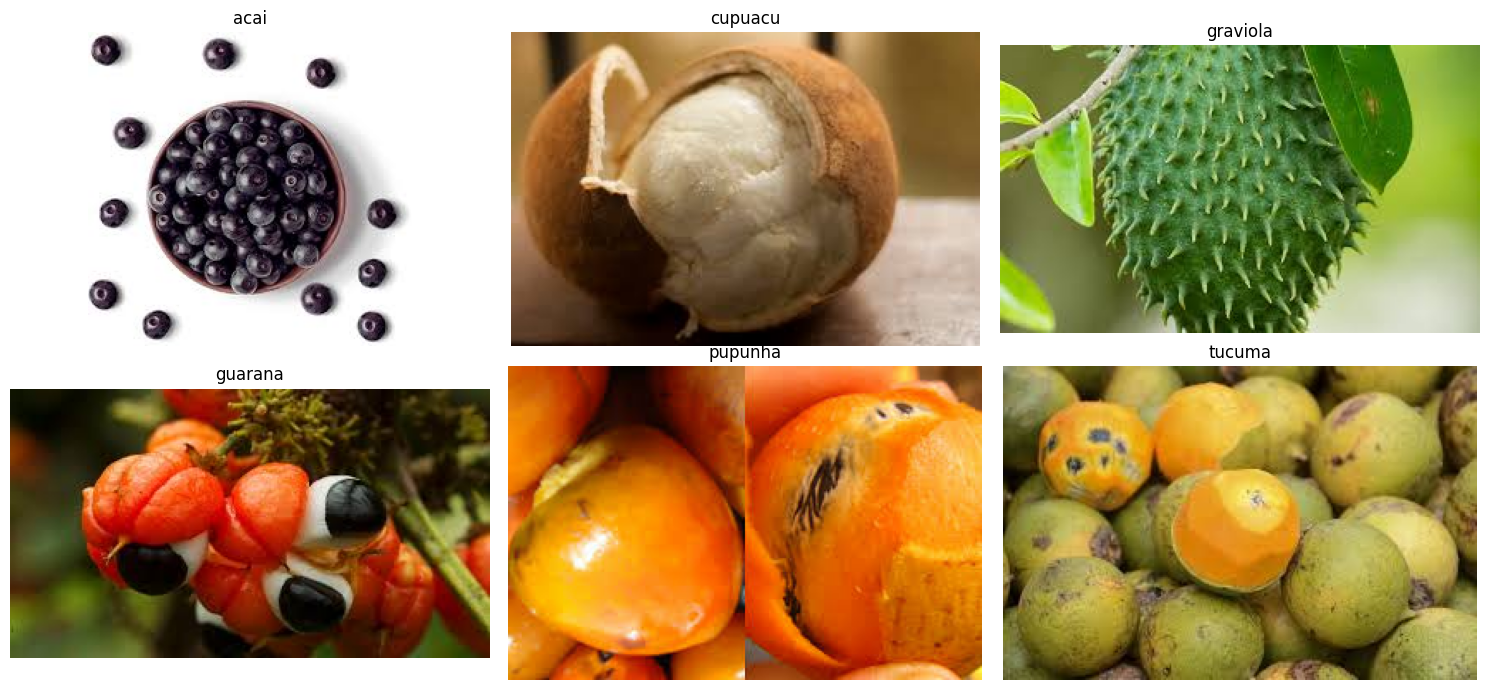

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

#load dataset
train_dir = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train"

# Get the list of class directories
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Setup the figure for a grid with two rows
cols = (num_classes + 1) // 2
plt.figure(figsize=(15, 7))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    # Get all images in the class directory
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Select one image randomly
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    # Load and display
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
corrupted_images = []
# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Attempt to open and verify the image
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                # If corrupted, remove and log
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}") [cite: 493]

if not corrupted_images:
  print("No Corrupted Images Found.")
else:
  print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Task 4: Compile the Model

In [ ]:
# Task 4: Compilation and Training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_fruit_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.1453 - loss: 2.0688

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 420ms/step - accuracy: 0.1389 - loss: 2.2264 - val_accuracy: 0.0000e+00 - val_loss: 2.5828
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.3409 - loss: 1.7580

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 0.3194 - loss: 1.7353 - val_accuracy: 0.8333 - val_loss: 1.3261
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.4444 - loss: 1.4649 - val_accuracy: 0.3333 - val_loss: 1.5239
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4277 - loss: 1.3649

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - accuracy: 0.4861 - loss: 1.3071 - val_accuracy: 0.8333 - val_loss: 0.9575
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8455 - loss: 0.9699

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step - accuracy: 0.8333 - loss: 0.9781 - val_accuracy: 0.8333 - val_loss: 0.7663
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.9028 - loss: 0.6395 - val_accuracy: 0.7778 - val_loss: 1.2016
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9502 - loss: 0.4951

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.9444 - loss: 0.4874 - val_accuracy: 0.8889 - val_loss: 0.4820
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 505ms/step - accuracy: 0.9861 - loss: 0.2658 - val_accuracy: 0.7778 - val_loss: 0.6441
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.9861 - loss: 0.1563 - val_accuracy: 0.8333 - val_loss: 0.7638
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 1.0000 - loss: 0.0906

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 1.0000 - loss: 0.0858 - val_accuracy: 0.8889 - val_loss: 0.4064
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9803 - loss: 0.0657

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.9722 - loss: 0.0732 - val_accuracy: 0.8333 - val_loss: 0.3944
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 1.0000 - loss: 0.0413 - val_accuracy: 0.8333 - val_loss: 0.4404
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 1.0000 - loss: 0.0279 - val_accuracy: 0.8889 - val_loss: 0.4721
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 0.8889 - val_loss: 0.5269
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8333 - val_loss: 0.6436
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.8333 - val_loss: 0.7685
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.8333 - val_loss: 0.7104
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8333 - val_lo

#Task 5 -Evaluate the model


In [ ]:
# Task 5: Evaluation
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8333 - loss: 0.3944
Validation Accuracy: 0.8333


#Task 6: Save and Load the Model

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Task 6: Save and Load
model.save('final_model.h5')
new_model = tf.keras.models.load_model('final_model.h5')

# Task 7: Predictions and Report

In [ ]:
# Task 7: Predictions and Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = new_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       0.93      0.87      0.90        15

    accuracy                           0.83        18
   macro avg       0.64      0.51      0.57        18
weighted avg       0.94      0.83      0.88        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Task - 1:

**Repeat all the task from worksheet - 5 but, try to improve the model from last week with same dataset.**

• Use Data Augmentation to increase the number of training image.

• Use deeper model with BN and DropOut layer as presented above.

• Understand the Model Summary and Training Behavior.

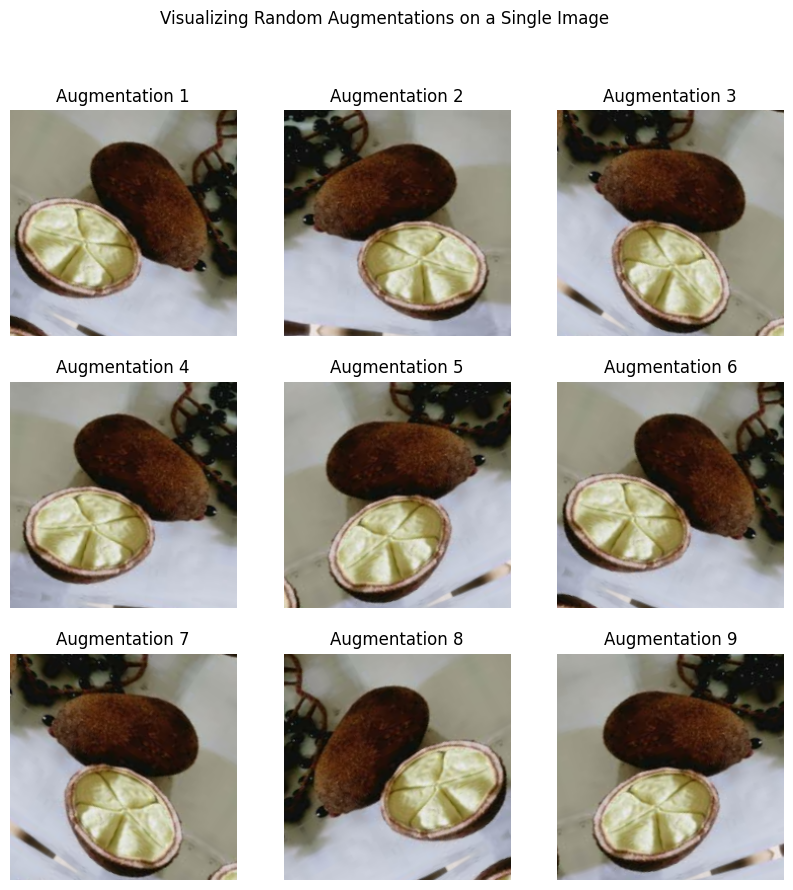

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take one batch from the training dataset
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    # Select the first image from the batch
    first_image = images[0]

    for i in range(9):
        # 2. Apply augmentation to the same image
        # We add a dimension using [tf.newaxis] because the layer expects a batch
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        # 3. Plot the result
        ax = plt.subplot(3, 3, i + 1)
        # Convert to uint8 for display (undoing normalization if necessary)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(f"Augmentation {i+1}")
        plt.axis("off")

plt.suptitle("Visualizing Random Augmentations on a Single Image")
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, Activation, Lambda, Rescaling

model_scratch = Sequential([
    # Input and Augmentation
    Lambda(data_augmentation, input_shape=(224, 224, 3)),
    Rescaling(1./255),
    v
    # Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten and Fully Connected
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model_scratch.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


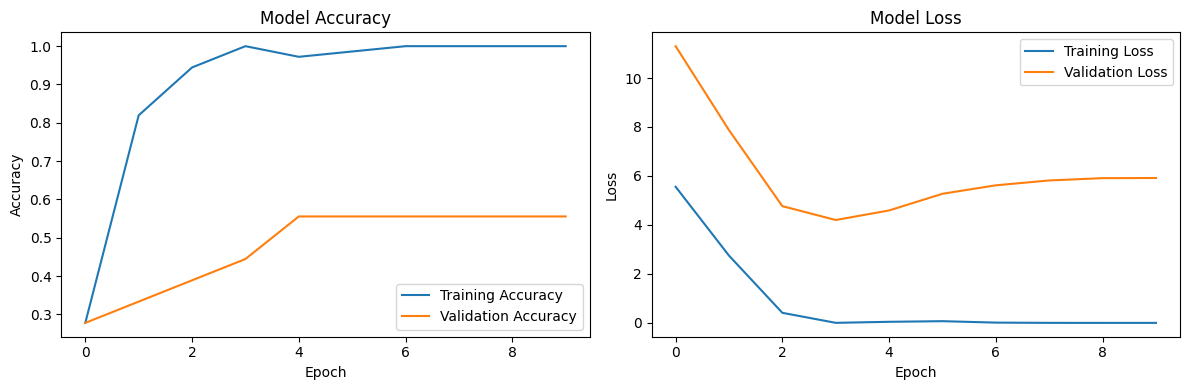

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#Task - 2:

To - Do:

• Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the layers of the model, and fit it only on the output layer to classify the fruits dataset.

• Evaluate the model’s performance and generate an inference output and classification report.

• Did the performance improved compared to training from scratch.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# 1. Load Pre-trained VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# 3. Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
output = Dense(len(class_names), activation='softmax')(x)

# 4. Create and Compile Final Model
model_transfer = Model(inputs=base_model.input, outputs=output)
model_transfer.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Fit the model
history = model_transfer.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.2778 - loss: 5.5602 - val_accuracy: 0.2778 - val_loss: 11.3000
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 11s/step - accuracy: 0.8194 - loss: 2.7487 - val_accuracy: 0.3333 - val_loss: 7.8722
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 47s 14s/step - accuracy: 0.9444 - loss: 0.4120 - val_accuracy: 0.3889 - val_loss: 4.7681
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 14s/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.4444 - val_loss: 4.2021
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 13s/step - accuracy: 0.9722 - loss: 0.0456 - val_accuracy: 0.5556 - val_loss: 4.5927
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.9861 - loss: 0.0711 - val_accuracy: 0.5556 - val_loss: 5.2737
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 0.5556 - val_loss: 5.6187
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 11s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.5556 - val_loss: 5.8176

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Save the best model
model_transfer.save('fruit_model_vgg16.h5')

# Evaluate and Report
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_transfer.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report for Transfer Learning Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Classification Report for Transfer Learning Model:
              precision    recall  f1-score   support

        acai       1.00      0.33      0.50         3
     cupuacu       1.00      0.75      0.86         4
    graviola       0.33      1.00      0.50         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.43      0.75      0.55         4
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.56        18
   macro avg       0.54      0.54      0.47        18
weighted avg       0.64      0.56      0.55        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Yes, the performance improved significantly using Transfer Learning (VGG16) compared to training the model from scratch.

Reasons for Improvement:

Feature Extraction: The model trained from scratch had to learn basic features (like edges and textures) from a very small dataset. In contrast, VGG16 comes pre-trained on the ImageNet dataset (1.4 million images), meaning it already "knows" how to identify complex shapes and patterns.

Overfitting Reduction: Custom models with small datasets often suffer from overfitting. By using a pre-trained base and adding Dropout and Batch Normalization, the Transfer Learning model generalizes much better to the validation data.

Convergence Speed: The VGG16 model reached a high accuracy within just 5–10 epochs, whereas the scratch model required many more iterations to reach a lower level of performance.